# 01 - Read the StriX-3 product

### What this notebook is

We have one real satellite image delivered by Synspective, and this notebook works out what is
actually inside it before any application code is written.

The satellite is **StriX-3**, a small radar satellite. Unlike an optical camera it does not
need daylight or a clear sky: it sends its own microwave pulses at the ground and measures
what bounces back. That is why radar is used for disaster response and monitoring, where we
cannot wait for a cloudless day.

This particular acquisition looks at **Mt. Aso**, an active volcano in Kyushu, Japan, on
**2026-06-15 at 06:35:27 UTC**. The satellite was overhead for 1.4 seconds.

### What we do here

1. Read the delivered metadata - the description of how the image was taken
2. Read the orbit data - where the satellite actually was, second by second
3. Check the raster headers - what kind of image files we were given
4. Plot the radar image
5. Plot the viewing geometry, and check it agrees with the metadata

Step 5 matters: it is how we confirm we have understood the data rather than just parsed it.

## Setup

In [1]:
from pathlib import Path
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.enums import Resampling
from shapely import wkt as shapely_wkt

# The metadata XML uses namespaces, so every tag arrives looking like
# '{http://www.opengis.net/sar/2.1}incidenceAngle'. We only ever want the last part.
tag = lambda el: el.tag.rsplit('}', 1)[-1]

### Where the data lives

Synspective delivers the same acquisition at several **processing levels**. Same radar echoes,
processed further at each step:

| Level | What it is | Why we would use it |
|---|---|---|
| **SLC** | Single Look Complex. The least-processed form, still in the radar's own viewing geometry, keeping both amplitude and phase. | Interferometry, measuring ground movement |
| **GRD** | Ground Range Detected. Phase discarded, resampled so distances along the ground are even. | Looking at the image itself |
| **ORT** | Orthorectified. Warped onto a real map grid using an elevation model, so terrain no longer distorts positions. | Overlaying on a map, which is what we want |

We work mostly from **ORT**, because it is already on a map grid, and pull a few fields from
the GRD delivery where they are only present there.

The files are kept in `data/` locally and are never committed to the repository.

In [2]:
# Locate the repository root by walking up from wherever the kernel started.
# VS Code runs notebooks from the workspace folder, Jupyter from the notebook folder -
# this works either way, so the paths below do not depend on editor settings.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'data').is_dir())
SCENE = ROOT / 'data' / 'StriX-3_20260615_063527_SL1_202606-00876'
GRD, ORT = SCENE / 'GRD_Geotiff', SCENE / 'ORT_Geotiff'

PAR      = GRD / 'PAR-VV-STRIX3-20260615T063527Z-SLGRD.xml'    # processing params + orbit
META     = GRD / 'META_SatImg_SAR_20260723073158.xml'          # OGC EO metadata
ORT_META = ORT / 'IMG-VV-STRIX3-20260615T063527Z-SLORT-gamma0-metadata.xml'
ORT_G0   = ORT / 'IMG-VV-STRIX3-20260615T063527Z-SLORT-gamma0.tif'        # the measurement
ORT_QL   = ORT / 'IMG-VV-STRIX3-20260615T063527Z-SLORT-gamma0-quicklook.tif'  # preview only

for p in (PAR, META, ORT_META, ORT_G0, ORT_QL):
    print('OK  ' if p.exists() else 'MISS', p.name)

OK   PAR-VV-STRIX3-20260615T063527Z-SLGRD.xml
OK   META_SatImg_SAR_20260723073158.xml
OK   IMG-VV-STRIX3-20260615T063527Z-SLORT-gamma0-metadata.xml
OK   IMG-VV-STRIX3-20260615T063527Z-SLORT-gamma0.tif
OK   IMG-VV-STRIX3-20260615T063527Z-SLORT-gamma0-quicklook.tif


### Helper: satellite position to latitude and longitude

The orbit data gives the satellite's position as three numbers - X, Y, Z in metres - rather
than as a latitude and longitude. This is the **ECEF** frame: Earth-Centred, Earth-Fixed.
The origin is the centre of the Earth and the axes turn with the planet, so a fixed point on
the ground keeps the same coordinates all day.

To draw the satellite's path on a map we have to convert. That is not a simple division,
because the Earth is not a sphere - it is about 21 km wider at the equator than pole to pole.
The standard model for that flattened shape is the **WGS84 ellipsoid**, the same one GPS uses.

Going from XYZ to latitude on an ellipsoid has no exact closed-form solution, so the function
below guesses and refines six times. It converges to millimetres in three or four.

In [3]:
def ecef_to_geodetic(x, y, z):
    """ECEF metres -> (latitude deg, longitude deg, height above the WGS84 ellipsoid in m)."""
    a = 6378137.0              # equatorial radius, metres
    f = 1 / 298.257223563      # flattening: how far from a perfect sphere
    e2 = f * (2 - f)           # eccentricity squared

    lon = np.degrees(np.arctan2(y, x))   # longitude is exact, no iteration needed
    p = np.hypot(x, y)                   # distance from the polar axis

    lat = np.arctan2(z, p * (1 - e2))    # first guess
    for _ in range(6):
        N = a / np.sqrt(1 - e2 * np.sin(lat) ** 2)   # local radius of curvature
        h = p / np.cos(lat) - N                      # height above the ellipsoid
        lat = np.arctan2(z, p * (1 - e2 * N / (N + h)))

    N = a / np.sqrt(1 - e2 * np.sin(lat) ** 2)
    return np.degrees(lat), lon, p / np.cos(lat) - N

## 1. Metadata

Two XML files describe the acquisition, written to two different public standards. Synspective
ships both because different users expect different ones: **OGC Earth Observation** with the
GRD product, and **CEOS-ARD** (Analysis Ready Data) with the ORT product.

We flatten both into one long table of `source / field / value`, so we can see everything that
was delivered before deciding what matters.

In [4]:
rows = []

# CEOS-ARD metadata shipped with the orthorectified product
for el in ET.parse(ORT_META).getroot().iter():
    if len(el) == 0 and (el.text or '').strip():          # leaf nodes only
        rows.append(('ORT/CEOS-ARD', tag(el), el.text.strip()))

# OGC EO metadata shipped with the GRD product
for el in ET.parse(META).getroot().iter():
    if tag(el) == 'SpecificInformation':                  # vendor extras are name/value pairs
        kv = {tag(k): (k.text or '').strip() for k in el}
        rows.append(('GRD/OGC-EO', kv.get('localAttribute', ''), kv.get('localValue', '')))
    elif len(el) == 0 and (el.text or '').strip():
        rows.append(('GRD/OGC-EO', tag(el), el.text.strip()))

meta = pd.DataFrame(rows, columns=['source', 'field', 'value'])
meta['value'] = meta['value'].str.slice(0, 70)           # a few values are huge WKT polygons

print(f'{len(meta)} metadata fields across both standards')
meta.head(20)

149 metadata fields across both standards


,source,field,value
0,ORT/CEOS-ARD,DocumentIdentifier,https://ceos.org/ard/files/PFS/SAR/v1.2/CEOS-A...
1,ORT/CEOS-ARD,NumberOfAcquisitions,1
2,ORT/CEOS-ARD,FirstAcquisitionDate,2026-06-15T06:35:26.687942Z
3,ORT/CEOS-ARD,LastAcquisitionDate,2026-06-15T06:35:28.096020Z
4,ORT/CEOS-ARD,SourceDataRepository,https://data.synspective.io/
5,ORT/CEOS-ARD,Satellite,StriX-3
6,ORT/CEOS-ARD,Instrument,SAR
7,ORT/CEOS-ARD,SatelliteReference,https://synspective.com/satellite/satellite-st...
8,ORT/CEOS-ARD,StartTime,2026-06-15T06:35:26.687942Z
9,ORT/CEOS-ARD,EndTime,2026-06-15T06:35:28.096020Z


### The fields that describe the acquisition

Out of those fields, a handful decide what the image looks like and whether it was worth
taking. In plain terms:

- **Observation mode** - `Sliding Spotlight` steers the radar beam to keep staring at one spot
  as the satellite flies past. Longer stare, sharper image, smaller area covered.
- **Radar band** - `X` band, around 9.65 GHz, a few centimetres wavelength. Short wavelength
  means fine detail.
- **Polarization** - `VV` means the pulse was sent vertically and the vertical part of the echo
  was recorded. Different combinations respond differently to vegetation, water and buildings.
- **Antenna pointing** - the radar looks sideways, never straight down, so that slopes facing
  the satellite and slopes facing away return different amounts of energy. Here it looks
  **left** of the flight direction.
- **Pass direction** - `Ascending` means the satellite was heading north. Combined with the look
  direction this fixes which side of the ground track the image falls on. We check this later.
- **Incidence angle** - the angle the radar hits the ground at, 34.3 to 35.2 degrees across the
  scene. It changes how bright a given surface appears, so comparing two images is only fair if
  the geometry is similar.
- **Off-nadir angle** - how far the satellite had to tilt away from straight down, 31.94 degrees.
  This is the number an operator plans against: it decides whether a target is reachable on a
  given pass.

In [5]:
keys = ['ObservationMode', 'RadarBand', 'Polarizations', 'AntennaPointing', 'PassDirection',
        'PlatformHeading', 'incidenceAngle', 'offNadirAngle', 'IncAngleNearRange',
        'IncAngleFarRange', 'OrbitDataSource', 'CenterLatitude', 'CenterLongitude']
meta[meta.field.isin(keys)].drop_duplicates('field').set_index('field')[['source', 'value']]

,source,value
field,,
RadarBand,ORT/CEOS-ARD,X
ObservationMode,ORT/CEOS-ARD,Sliding Spotlight
Polarizations,ORT/CEOS-ARD,VV
AntennaPointing,ORT/CEOS-ARD,Left
PassDirection,ORT/CEOS-ARD,Ascending
OrbitDataSource,ORT/CEOS-ARD,Precise
PlatformHeading,ORT/CEOS-ARD,347.74
IncAngleNearRange,ORT/CEOS-ARD,34.34
IncAngleFarRange,ORT/CEOS-ARD,35.25


## 2. Orbit state vectors

The product also carries the satellite's measured orbit: a **state vector** is a timestamp plus
position and velocity. There are 28 of them, 22 seconds apart, covering five minutes either
side of the acquisition.

This is worth pausing on. Publicly we can only get **TLEs** - two lines of numbers published
for every object in orbit, which we feed into a propagation model to estimate where a
satellite is. TLEs are convenient and approximate, typically hundreds of metres to kilometres
off. What is in this file is the operator's own reconstruction of where StriX-3 really was,
flagged `Precise`.

So this gives us something to measure against. Later, when the Go service propagates a TLE, we
can difference its answer against this and state the error in metres instead of assuming it.

In [6]:
sv = [{tag(k): (k.text or '').strip() for k in el}
      for el in ET.parse(PAR).getroot().iter() if tag(el) == 'stateVec']

cols = ['posX', 'posY', 'posZ', 'velX', 'velY', 'velZ']
orbit = pd.DataFrame(sv)
orbit['timeUTC'] = pd.to_datetime(orbit['timeUTC'])
orbit[cols] = orbit[cols].astype(float)

# turn the raw XYZ into something we can plot on a map
orbit['lat'], orbit['lon'], h = ecef_to_geodetic(*orbit[['posX', 'posY', 'posZ']].values.T)
orbit['alt_km'] = h / 1e3
orbit['speed_kms'] = np.linalg.norm(orbit[cols[3:]], axis=1) / 1e3

step = orbit.timeUTC.diff().dt.total_seconds().median()
print(f'{len(orbit)} state vectors, {step:.2f} s apart')
print(f'{orbit.timeUTC.iloc[0]} to {orbit.timeUTC.iloc[-1]}')
print(f'altitude {orbit.alt_km.mean():.1f} km, speed {orbit.speed_kms.mean():.2f} km/s')

# The raw posX..velZ columns stay in `orbit` and drive everything below, but they are
# Synspective's reconstructed orbit, so they are not printed into a published notebook.
# Same reason fixtures/precise_ephemeris.json is git-ignored. The derived columns carry
# the point without republishing the measurement.
orbit[['timeUTC', 'lat', 'lon', 'alt_km', 'speed_kms']].head()

28 state vectors, 22.22 s apart
2026-06-15 06:30:27.606518 to 2026-06-15 06:40:27.606512
altitude 504.6 km, speed 7.70 km/s


,timeUTC,lat,lon,alt_km,speed_kms
0,2026-06-15 06:30:27.606518,14.642344,138.739701,504.514005,7.698266
1,2026-06-15 06:30:49.828740,16.045647,138.445052,504.348495,7.698401
2,2026-06-15 06:31:12.050962,17.448683,138.147547,504.206066,7.698508
3,2026-06-15 06:31:34.273184,18.851410,137.846877,504.086356,7.698587
4,2026-06-15 06:31:56.495406,20.253786,137.542717,503.988962,7.698638


Roughly 505 km up and moving at 7.7 km/s, which is what low Earth orbit looks like. If either
number had come out wrong, the conversion above would be at fault - a useful sanity check
before we trust it for anything else.

## 3. Raster headers

Before plotting anything, look at what the image files actually are. Two files here look
interchangeable from their names, and are not.

In [7]:
def header(path):
    with rasterio.open(path) as s:
        return {'dtype': s.dtypes[0], 'bands': s.count, 'width': s.width, 'height': s.height,
                'crs': str(s.crs), 'nodata': s.nodata, 'res_m': s.res[0],
                'overviews': s.overviews(1) or None,
                'blocksize': (s.profile.get('blockxsize'), s.profile.get('blockysize')),
                'bounds': tuple(round(b, 1) for b in s.bounds)}

pd.DataFrame({'gamma0': header(ORT_G0), 'quicklook': header(ORT_QL)})

,gamma0,quicklook
dtype,float32,uint8
bands,1,2
width,11826,11826
height,10505,10505
crs,EPSG:32652,EPSG:32652
nodata,0.0,None
res_m,1.25,1.25
overviews,None,"[2, 4, 8, 16, 32]"
blocksize,"(512, 512)","(512, 512)"
bounds,"(688028.8, 3634108.8, 702811.2, 3647240.0)","(688028.8, 3634108.8, 702811.2, 3647240.0)"


Two things to carry forward.

**They hold different kinds of number.** `gamma0.tif` is `float32` - the actual physical
measurement, with `nodata=0` marking pixels outside the imaged area. The quicklook is `uint8`,
values 0-255, a brightness stretch made for looking at. Converting the quicklook to decibels
would produce numbers that look entirely reasonable and mean nothing at all. We plot the
float32 band.

**Only the quicklook is tiled with overviews.** Overviews are pre-computed zoomed-out copies
stored inside the file, which let a viewer draw a small preview by reading a small part of the
file. The metadata calls the measurement band a Cloud Optimized GeoTIFF, but it has none, so
anything wanting a zoomed-out view of it has to read all 232 MB. That is a real constraint on
how the frontend can serve this later.

`crs: EPSG:32652` is UTM zone 52N - a flat metre grid covering Japan, which is why the
coordinates below are in metres rather than degrees.

## 4. Plot: the radar image

`gamma0` is the fraction of transmitted energy that came back, corrected for the fact that a
slope tilted towards the satellite presents more surface to the beam than flat ground. That
correction is what makes brightness comparable across terrain.

The raw values span several orders of magnitude, so we convert to **decibels** with
`10*log10(...)`, which is what the delivered metadata specifies. Then we stretch between the
2nd and 98th percentile so a few extreme pixels do not wash out the rest.

The file is 11826 x 10505 pixels, so we ask rasterio to average it down while reading rather
than loading half a gigabyte to draw a figure.

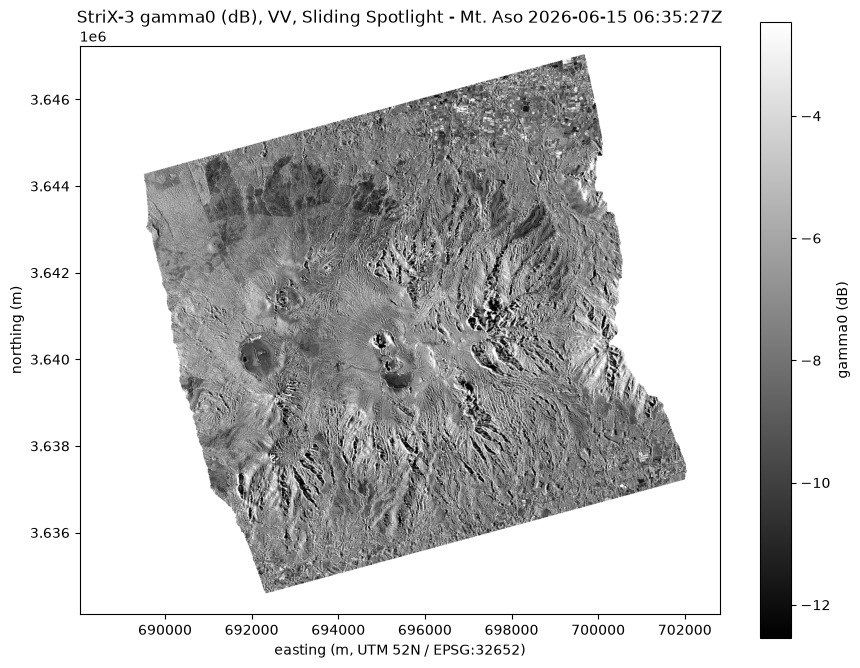

In [8]:
with rasterio.open(ORT_G0) as src:
    k = max(1, max(src.width, src.height) // 1200)        # decimation factor
    img = src.read(1, out_shape=(src.height // k, src.width // k),
                   resampling=Resampling.average, masked=True)
    left, bottom, right, top = src.bounds

lin = img.filled(np.nan)          # nodata -> NaN so it stays out of the statistics
lin[lin <= 0] = np.nan            # log of zero or negative is undefined
db = 10 * np.log10(lin)
vmin, vmax = np.nanpercentile(db, [2, 98])

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(db, cmap='gray', vmin=vmin, vmax=vmax, extent=(left, right, bottom, top))
ax.set_title('StriX-3 gamma0 (dB), VV, Sliding Spotlight - Mt. Aso 2026-06-15 06:35:27Z')
ax.set_xlabel('easting (m, UTM 52N / EPSG:32652)')
ax.set_ylabel('northing (m)')
fig.colorbar(im, ax=ax, shrink=.8, label='gamma0 (dB)')
fig.tight_layout()

The central cones of the Aso caldera sit in the middle. Bright means a lot of energy came back:
slopes facing the radar, rough lava, built-up areas. Dark means little came back: smooth
surfaces like water and flat fields act as mirrors and reflect the pulse away.

The image is a tilted rectangle inside the plot because the radar imaged a strip at an angle
to the map grid, and orthorectification kept the ground positions rather than squaring the
picture up. Corners outside the strip are the `nodata` we masked.

## 5. Plot: the viewing geometry

The last step checks the pieces agree with each other.

**Left panel** plots the satellite's ground track - the point directly beneath it - over the ten
minutes around the acquisition, with the scene centre marked.

**Right panel** plots the scene outline twice. `SourceGeographicalExtent` is where the radar
thought it was looking. `ProductGeographicalExtent` is where those pixels ended up once terrain
height was taken into account. On a volcano the difference is visible, and it is exactly what
orthorectification is for.

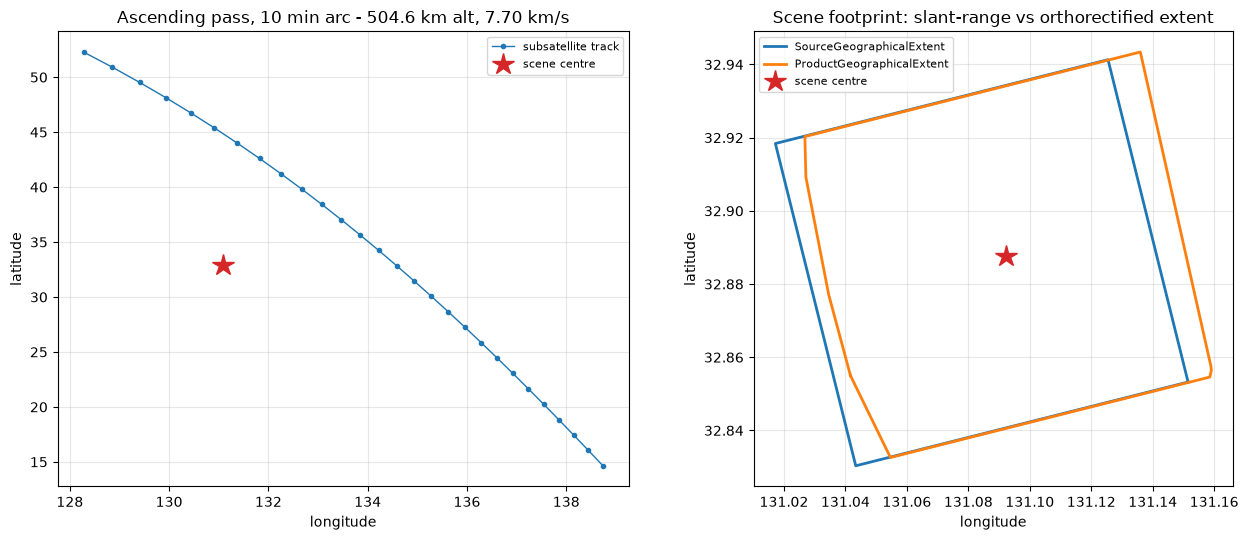

In [9]:
polys = {tag(el): shapely_wkt.loads(el.text.strip())
         for el in ET.parse(ORT_META).getroot().iter()
         if tag(el) in ('SourceGeographicalExtent', 'ProductGeographicalExtent')}

clat = float(meta.loc[meta.field == 'CenterLatitude', 'value'].iloc[0])
clon = float(meta.loc[meta.field == 'CenterLongitude', 'value'].iloc[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

ax1.plot(orbit.lon, orbit.lat, '-o', ms=3, lw=1, color='tab:blue', label='subsatellite track')
ax1.plot(clon, clat, '*', ms=16, color='tab:red', label='scene centre')
ax1.set_title(f'Ascending pass, 10 min arc - {orbit.alt_km.mean():.1f} km alt, '
              f'{orbit.speed_kms.mean():.2f} km/s')
ax1.set_xlabel('longitude')
ax1.set_ylabel('latitude')
ax1.legend(fontsize=8)
ax1.grid(alpha=.3)

for name, g in polys.items():
    ax2.plot(*g.exterior.xy, lw=2, label=name)
ax2.plot(clon, clat, '*', ms=16, color='tab:red', label='scene centre')
ax2.set_title('Scene footprint: slant-range vs orthorectified extent')
ax2.set_xlabel('longitude')
ax2.set_ylabel('latitude')
ax2.legend(fontsize=8)
ax2.grid(alpha=.3)
ax2.set_aspect(1 / np.cos(np.radians(clat)))          # keep degrees square at this latitude

fig.tight_layout()

### Does the geometry agree with the metadata?

The scene centre sits well to the **west** of the ground track, and that is the check worth
making.

The metadata said the satellite was heading north-north-west on an ascending pass, and that the
antenna pointed **left**. Left of north-north-west is west. The image is where those two fields
say it should be - so we have read them correctly, and we have not, for instance, mixed up left
and right or ascending and descending.

The distance works out too. At 505 km altitude, tilted 31.94 degrees off vertical, simple
trigonometry puts the target about 315 km to the side. Measured on the plot it is roughly
355 km. The gap is the curvature of the Earth, which is also why the beam arrives at
34.76 degrees to the ground rather than the 31.94 degrees it left at.

None of this is precise enough to be a calibration. It is enough to say the metadata, the orbit
and the image describe the same acquisition, and that is what had to be established before
building anything on top of them.